# RTM · Acoustic · Marmousi

Reverse-time migration takes recorded seismic data + a **smooth
background velocity model** and produces a reflectivity image by
cross-correlating the forward-propagated source wavefield with the
back-propagated data residual.

This notebook walks through the standard recipe on Marmousi at the
full ``12.5 m`` grid:

1. Forward-model **observed** data with the true ``vp`` and a
   high-frequency Ricker (better vertical resolution than the 5 Hz
   FWI source used in notebook 01).
2. Forward-model **background** data with the smooth ``vp``; their
   difference is the reflection-only residual.
3. Restrict the residual to **near offsets** so the image is built
   from near-normal-incidence reflections (suppresses migration
   smiles from far-offset diving energy).
4. Run ``solver.rtm(..., adjoint_source=residual_near)`` per shot,
   accumulating the per-shot image and the **source-side
   illumination** map.
5. Apply illumination compensation ``image / (src_illum + ε)`` to
   normalise away the strong near-source amplitude bias.


## 1. Parameters

In [1]:
import time
import numpy as np
import torch
import matplotlib.pyplot as plt

from sweep.equations import Acoustic
from sweep.propagator.torch import PropTorch
from sweep.signal import ricker
from sweep.datasets import load_marmousi, MARMOUSI_DH

dh   = MARMOUSI_DH       # 12.5 m
dt   = 1e-3
nt   = 4000              # 4.0 s
freq = 15.0              # higher than the 5 Hz FWI source → better image resolution
delay = 0.12
abcn = 50
spatial_order = 8         # high-freq run; bump stencil for less grid dispersion

nshots = 30
nrec   = 400              # one receiver every ~50 m on the surface
src_z, rec_z = 2, 4

# RTM-specific: only accept residual traces within this offset of the
# shot for imaging. Suppresses migration smile from far-offset diving
# energy and produces a near-vertical-incidence reflectivity image.
near_offset_m = 1500.0

# Batch shots into RTM groups to control peak GPU memory:
rtm_batch_size = 4

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)


device: cuda


## 2. True + smooth background models, geometry overlay

Same `(true, smooth)` Marmousi pair as notebook 01. The reflectivity
RTM will recover is essentially the difference between these two
models filtered through the wave operator.


shape: (281, 1361)   physical: 3.5 km × 17.0 km


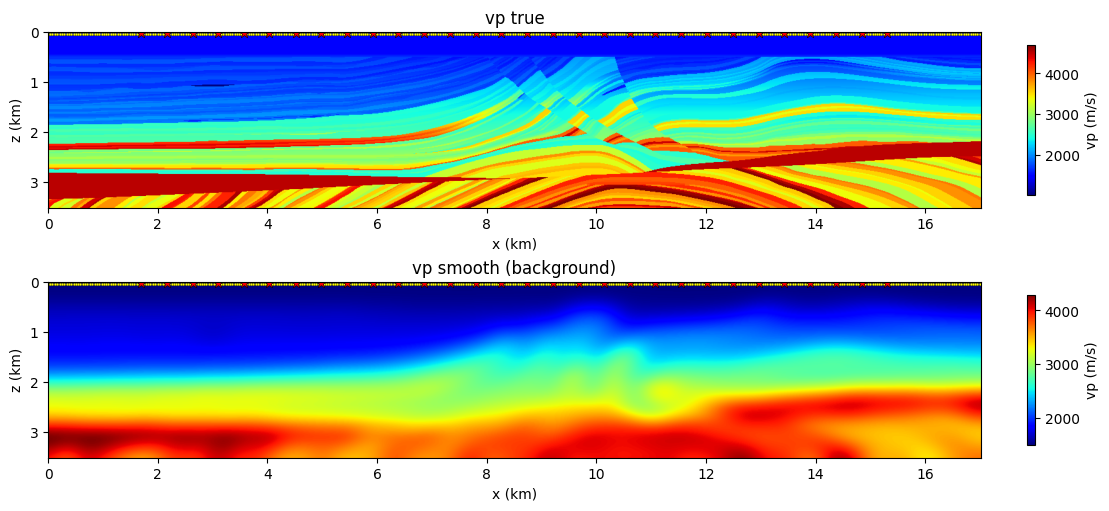

In [2]:
vp_true_np   = load_marmousi('true')
vp_smooth_np = load_marmousi('smooth')
shape = vp_true_np.shape
nz, nx = shape
print('shape:', shape, '  physical:',
      f'{shape[0]*dh/1000:.1f} km × {shape[1]*dh/1000:.1f} km')

# Geometry: shots spanning 10–90% of the surface; dense receiver line.
src_x = np.linspace(shape[1] * 0.1, shape[1] * 0.9, nshots).astype(np.int64)
rec_x = np.linspace(0, shape[1] - 1, nrec).astype(np.int64)
src_x_km = src_x * dh / 1000
rec_x_km = rec_x * dh / 1000

fig, axes = plt.subplots(2, 1, figsize=(11, 5), constrained_layout=True)
for ax, m, title in zip(axes, [vp_true_np, vp_smooth_np], ['true', 'smooth (background)']):
    im = ax.imshow(m, cmap='jet', aspect='auto',
                   extent=[0, shape[1]*dh/1000, shape[0]*dh/1000, 0])
    ax.scatter(rec_x_km, np.full_like(rec_x_km, rec_z*dh/1000, dtype=float),
               s=4, c='yellow', edgecolors='k', linewidths=0.2)
    ax.scatter(src_x_km, np.full_like(src_x_km, src_z*dh/1000, dtype=float),
               s=60, c='red', marker='*', edgecolors='k', linewidths=0.4)
    ax.set_title(f'vp {title}')
    ax.set_xlabel('x (km)'); ax.set_ylabel('z (km)')
    fig.colorbar(im, ax=ax, label='vp (m/s)', shrink=0.85)
plt.show()


## 3. Build the solver and forward-model observed + background data

RTM in SWEEP's compiled CUDA path supports **full-wavefield** mode
only (no checkpointing/boundary saving — the imaging condition
needs the entire forward trajectory at backward time). We pass
``use_ckpt=False`` for clarity.


In [3]:
t = np.arange(nt, dtype=np.float32) * dt
wavelet = ricker(t - delay, f=freq)

sources   = np.stack([src_x, np.full(nshots, src_z, dtype=np.int64)], axis=1)
receivers = np.stack([rec_x, np.full(nrec, rec_z, dtype=np.int64)], axis=1)
receivers = np.repeat(receivers[None, ...], nshots, axis=0)

equation = Acoustic(device=device, spatial_order=spatial_order)
solver = PropTorch(equation, shape=shape, dh=dh, dt=dt, nt=nt,
                   abcn=abcn, impl='c', use_ckpt=False)
print('impl:', solver.impl, ' use_ckpt:', solver.use_ckpt)

vp_true_t   = torch.tensor(vp_true_np,   device=device)
vp_smooth_t = torch.tensor(vp_smooth_np, device=device)

with torch.no_grad():
    observed   = solver(wavelet, sources, receivers, models=[vp_true_t]).detach()
    background = solver(wavelet, sources, receivers, models=[vp_smooth_t]).detach()
residual = observed - background
print('residual:', tuple(residual.shape))


impl: c  use_ckpt: False


residual: (30, 4000, 400, 1)


### Aside · which sources and receivers does this equation accept?

`Acoustic` publishes a structured field table — query `eq.models` for the
expected model input order, `available_source_fields()` / `available_receiver_fields()`
for valid source / receiver options. See the
[Equations user guide](../../user-guide/equations/) for the full rundown.

In [4]:
print('models (input order matters!):')
for spec in equation.MODEL_SPECS:
    unit = f' [{spec.unit}]' if spec.unit else ''
    print(f'  - {spec.name:8s}{unit}  — {spec.description}')
print('defaults  :', equation.default_source_fields, '/', equation.default_receiver_fields)
print('receivers :')
for spec in equation.available_receiver_fields():
    print(f'  - {spec.name:8s} aliases={spec.aliases}  — {spec.description}')

models (input order matters!):
  - vp       [m/s]  — Acoustic P-wave velocity model.
defaults  : ['h1'] / ['h1']
receivers :
  - h1       aliases=('pressure', 'p')  — Primary acoustic pressure-like wavefield.


## 4. Near-offset + direct-wave mute

For each shot, zero out residual traces whose receiver–source
horizontal offset exceeds ``near_offset_m`` **and** zero samples
that arrive before the direct-wave first break (water-layer
velocity ``1500 m/s``) plus a ~1.5-wavelet-half-cycle buffer.
The two masks combine multiplicatively so the adjoint source is
purely subsurface-reflection energy.

Note: we do **not** enable ``free_surface=True`` — without a
free-surface BC the wavefield has no ghost or surface multiples
to confuse the direct-wave first-break estimate.


near-offset traces / shot: avg 71 / 400
direct-wave mute: buffer = 100 ms past first arrival


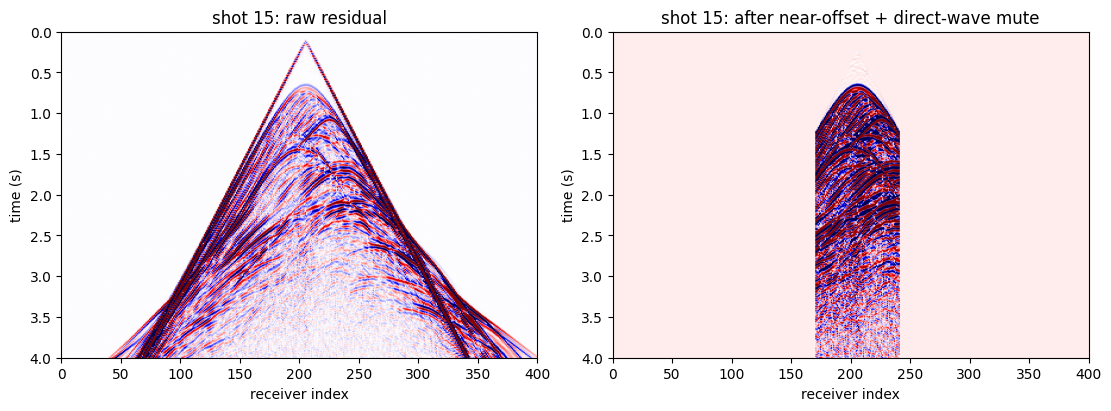

In [5]:
# Near-offset trace selection
offsets_m = np.abs(rec_x[None, :] - src_x[:, None]) * dh
near_mask = (offsets_m <= near_offset_m).astype(np.float32)

# Direct-wave top-mute. Surface acquisition with no free-surface BC:
# the direct wave travels at the water-layer velocity 1500 m/s. Compute
# its arrival time per (shot, receiver) and zero residual samples that
# arrive before that time + a half-wavelet buffer, leaving only the
# subsurface reflections for the imaging condition.
v_water = 1500.0
src_xz_m = sources * dh                                        # (nshots, 2)
rec_xz_m = receivers * dh                                      # (nshots, nrec, 2)
delta = rec_xz_m - src_xz_m[:, None, :]                        # (nshots, nrec, 2)
geom_offset = np.sqrt((delta ** 2).sum(axis=-1))               # (nshots, nrec)
t_direct = geom_offset / v_water + delay                       # arrival times
mute_buffer = 1.5 / freq                                       # ~1.5 wavelet half-cycles
time_axis = np.arange(nt, dtype=np.float32) * dt
after_direct = (time_axis[None, None, :] >
                (t_direct[..., None] + mute_buffer)).astype(np.float32)
                                                                # (nshots, nrec, nt)

near_mask_t  = torch.tensor(near_mask, device=device)[..., None, None]    # (ns, nr, 1, 1)
direct_mask_t = torch.tensor(after_direct.transpose(0, 2, 1),
                              device=device)[..., None]                   # (ns, nt, nr, 1)
# residual axis order: (nshots, nt, nrec, nfields=1)
residual_near = residual * direct_mask_t * near_mask_t.permute(0, 2, 1, 3)
print(f'near-offset traces / shot: avg {near_mask.sum(axis=1).mean():.0f} / {nrec}')
print(f'direct-wave mute: buffer = {mute_buffer*1000:.0f} ms past first arrival')

# Sanity peek: central shot, before vs after the combined mute
centre = nshots // 2
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
for ax, gather, label in zip(axes,
                              [residual[centre, :, :, 0].cpu().numpy(),
                               residual_near[centre, :, :, 0].cpu().numpy()],
                              ['raw residual',
                               'after near-offset + direct-wave mute']):
    vmin, vmax = np.percentile(gather, [2, 98])
    ax.imshow(gather, cmap='seismic', vmin=vmin, vmax=vmax, aspect='auto',
              extent=[0, nrec, nt * dt, 0])
    ax.set_xlabel('receiver index'); ax.set_ylabel('time (s)')
    ax.set_title(f'shot {centre}: {label}')
plt.show()


## 5. RTM loop with illumination compensation

``solver.rtm(wavelet, sources, receivers, adjoint_source=...,
models=...)`` returns ``(syn, image, source_illum, receiver_illum)``
for each shot in the batch. We sum the images across all shots and
divide by the summed source-side illumination ``+ ε`` to remove the
near-source amplitude bias.


In [6]:
image_sum     = torch.zeros((nz, nx), device=device, dtype=torch.float32)
src_illum_sum = torch.zeros((nz, nx), device=device, dtype=torch.float32)

t0 = time.time()
for start in range(0, nshots, rtm_batch_size):
    stop = min(start + rtm_batch_size, nshots)
    src_b = sources[start:stop]
    rec_b = receivers[start:stop]
    res_b = residual_near[start:stop].contiguous()
    _, image, src_illum, _ = solver.rtm(
        wavelet, src_b, rec_b, adjoint_source=res_b, models=[vp_smooth_t])
    # crop PML padding (abcn cells on each side) and sum over batch
    image_sum     += image[:, 0, abcn:abcn + nz, abcn:abcn + nx].sum(dim=0)
    src_illum_sum += src_illum[:, 0, abcn:abcn + nz, abcn:abcn + nx].sum(dim=0)
    print(f'  shots {start:3d}-{stop-1:3d} done  '
          f'cumulative {time.time()-t0:.1f}s')
torch.cuda.synchronize() if device.type == 'cuda' else None
print(f'total RTM time: {time.time()-t0:.1f}s')

image_np      = image_sum.detach().cpu().numpy()
illum_np      = src_illum_sum.detach().cpu().numpy()
eps           = 1e-3 * illum_np.max()
image_compensated = image_np / (illum_np + eps)

# Mute the water column: Marmousi's top ~37 cells are uniform vp=1500 m/s,
# the RTM image there is dominated by direct-wave reverberations not by
# subsurface reflectivity. Detect the water bottom from vp_true and zero
# everything above the seabed plus a small taper.
water_rows = int(np.where((vp_true_np == 1500.0).all(axis=1))[0][-1])
image_np[:water_rows + 1, :] = 0.0
image_compensated[:water_rows + 1, :] = 0.0
print(f'water bottom at row {water_rows} ({(water_rows+1)*dh:.0f} m); muted')


  shots   0-  3 done  cumulative 0.5s


  shots   4-  7 done  cumulative 1.0s


  shots   8- 11 done  cumulative 1.5s


  shots  12- 15 done  cumulative 2.0s


  shots  16- 19 done  cumulative 2.5s


  shots  20- 23 done  cumulative 3.1s


  shots  24- 27 done  cumulative 3.6s


  shots  28- 29 done  cumulative 3.8s
total RTM time: 3.8s
water bottom at row 36 (462 m); muted


## 6. Illumination-compensated image

Dividing the stacked image by the summed source-side illumination
rebalances amplitude with depth — every shot illuminates the
shallow part, so the raw stack is over-bright near the surface
and dim at depth. Compensation flattens that bias.


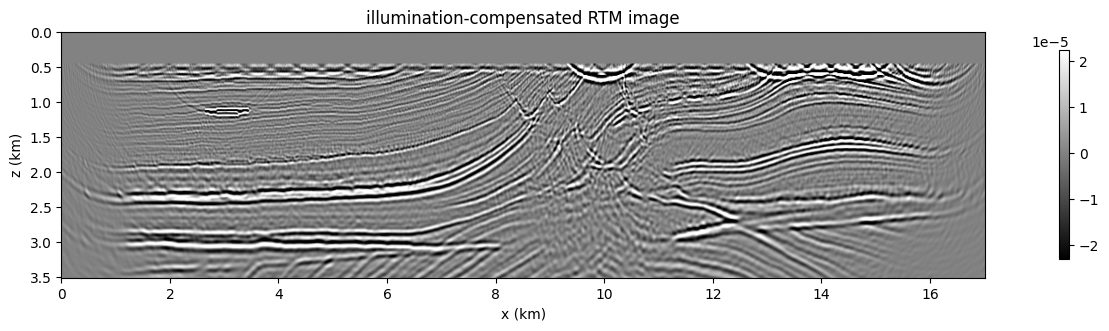

In [7]:
vmin, vmax = np.percentile(image_compensated, [2, 98])
fig, ax = plt.subplots(figsize=(11, 3.2), constrained_layout=True)
im = ax.imshow(image_compensated, cmap='gray', vmin=vmin, vmax=vmax,
               aspect='auto',
               extent=[0, shape[1]*dh/1000, shape[0]*dh/1000, 0])
ax.set_title('illumination-compensated RTM image')
ax.set_xlabel('x (km)'); ax.set_ylabel('z (km)')
fig.colorbar(im, ax=ax, shrink=0.85)
plt.show()


---

<p><strong>Download this notebook</strong> &mdash; <a href="08_rtm_acoustic_marmousi.ipynb" download><code>08_rtm_acoustic_marmousi.ipynb</code></a> &middot; or <a href="https://github.com/DeepWave-KAUST/sweep/blob/dev/examples/notebooks/08_rtm_acoustic_marmousi.ipynb">view on GitHub</a></p>
